probar clasificadores con sub=ajuste y sobre ajuste.

op 1) cross-validation (50/50), (40/60)

op 2) aumentar orden de los modelos sin justificacion (k=7 en KNN)

usar wine-dataser. breast cancer

LIBRERIAS

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine, load_breast_cancer
from sklearn.model_selection import (
    train_test_split,
    cross_validate,
    StratifiedKFold
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

sns.set_style("whitegrid")

CARGAR DATASETS

In [ ]:

wine = load_wine()
cancer = load_breast_cancer()

datasets = {
    "Wine": (wine.data, wine.target),
    "Breast Cancer": (cancer.data, cancer.target)
}

for nombre, (X, y) in datasets.items():
    print(f"\nDataset: {nombre}")
    print(f"Cantidad de observaciones: {X.shape[0]}")
    print(f"Cantidad de variables: {X.shape[1]}")
    print(f"Cantidad de clases: {len(np.unique(y))}")


Dataset: Wine
Cantidad de observaciones: 178
Cantidad de variables: 13
Cantidad de clases: 3

Dataset: Breast Cancer
Cantidad de observaciones: 569
Cantidad de variables: 30
Cantidad de clases: 2


PROBAR DIFERENTES PARTICIONES

In [ ]:
particiones = {
    "50/50": 0.50,
    "40/60": 0.60
}

resultados_particiones = []

for dataset_nombre, (X, y) in datasets.items():

    for particion_nombre, test_size in particiones.items():

        X_train, X_test, y_train, y_test = train_test_split(
            X,
            y,
            test_size=test_size,
            random_state=42,
            stratify=y
        )

        modelo = Pipeline([
            ("escalador", StandardScaler()),
            ("knn", KNeighborsClassifier(n_neighbors=7))
        ])

        modelo.fit(X_train, y_train)

        y_train_pred = modelo.predict(X_train)
        y_test_pred = modelo.predict(X_test)

        accuracy_train = accuracy_score(
            y_train,
            y_train_pred
        )

        accuracy_test = accuracy_score(
            y_test,
            y_test_pred
        )

        diferencia = accuracy_train - accuracy_test

        resultados_particiones.append({
            "Dataset": dataset_nombre,
            "Partición": particion_nombre,
            "Entrenamiento": len(X_train),
            "Prueba": len(X_test),
            "Accuracy train": accuracy_train,
            "Accuracy test": accuracy_test,
            "Diferencia": diferencia
        })

resultados_particiones_df = pd.DataFrame(
    resultados_particiones
)

resultados_particiones_df.round(4)

,Dataset,Partición,Entrenamiento,Prueba,Accuracy train,Accuracy test,Diferencia
0,Wine,50/50,89,89,0.9888,0.9326,0.0562
1,Wine,40/60,71,107,1.0000,0.9065,0.0935
2,Breast Cancer,50/50,284,285,0.9718,0.9614,0.0104
3,Breast Cancer,40/60,227,342,0.9736,0.9532,0.0204


VISUALIZAR LOS RESULTADOS

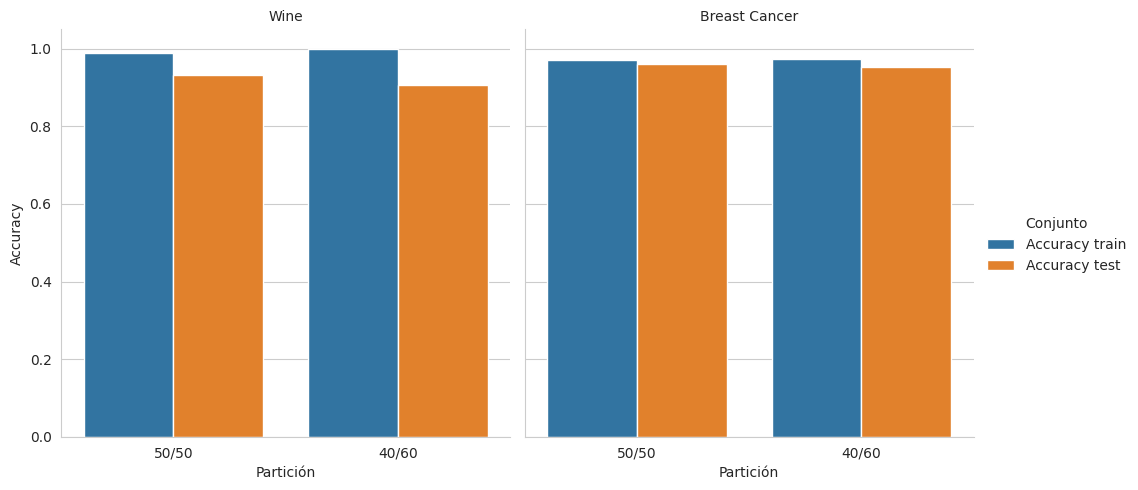

In [ ]:
resultados_largos = resultados_particiones_df.melt(
    id_vars=["Dataset", "Partición"],
    value_vars=["Accuracy train", "Accuracy test"],
    var_name="Conjunto",
    value_name="Accuracy"
)

g = sns.catplot(
    data=resultados_largos,
    x="Partición",
    y="Accuracy",
    hue="Conjunto",
    col="Dataset",
    kind="bar",
    height=5,
    aspect=1
)

g.set_titles("{col_name}")
g.set_axis_labels("Partición", "Accuracy")
g.set(ylim=(0, 1.05))

plt.show()

CROSS-VALIDATION

In [ ]:
resultados_cv = []

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

for dataset_nombre, (X, y) in datasets.items():

    for k in [1, 7, 50]:

        modelo = Pipeline([
            ("escalador", StandardScaler()),
            ("knn", KNeighborsClassifier(n_neighbors=k))
        ])

        resultado = cross_validate(
            modelo,
            X,
            y,
            cv=cv,
            scoring="accuracy",
            return_train_score=True
        )

        train_promedio = resultado[
            "train_score"
        ].mean()

        test_promedio = resultado[
            "test_score"
        ].mean()

        resultados_cv.append({
            "Dataset": dataset_nombre,
            "k": k,
            "Accuracy train": train_promedio,
            "Accuracy validación": test_promedio,
            "Diferencia": train_promedio - test_promedio,
            "Desviación validación":
                resultado["test_score"].std()
        })

resultados_cv_df = pd.DataFrame(resultados_cv)

resultados_cv_df.round(4)

,Dataset,k,Accuracy train,Accuracy validación,Diferencia,Desviación validación
0,Wine,1,1.0000,0.9551,0.0449,0.0223
1,Wine,7,0.9747,0.9719,0.0028,0.0252
2,Wine,50,0.9607,0.9608,-0.0001,0.0225
3,Breast Cancer,1,1.0000,0.9508,0.0492,0.0204
4,Breast Cancer,7,0.9728,0.9649,0.0079,0.0184
5,Breast Cancer,50,0.9521,0.9508,0.0013,0.0212


PROBAR DIFERENTES VALORES DE K

In [ ]:
valores_k = [
    1, 3, 5, 7, 10, 15, 20, 30, 50
]

resultados_k = []

for dataset_nombre, (X, y) in datasets.items():

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.50,
        random_state=42,
        stratify=y
    )

    for k in valores_k:

        # Evitar que k sea mayor que la cantidad de entrenamiento
        if k > len(X_train):
            continue

        modelo = Pipeline([
            ("escalador", StandardScaler()),
            ("knn", KNeighborsClassifier(n_neighbors=k))
        ])

        modelo.fit(X_train, y_train)

        accuracy_train = modelo.score(
            X_train,
            y_train
        )

        accuracy_test = modelo.score(
            X_test,
            y_test
        )

        resultados_k.append({
            "Dataset": dataset_nombre,
            "k": k,
            "Accuracy train": accuracy_train,
            "Accuracy test": accuracy_test,
            "Diferencia": accuracy_train - accuracy_test
        })

resultados_k_df = pd.DataFrame(resultados_k)

resultados_k_df.round(4)

,Dataset,k,Accuracy train,Accuracy test,Diferencia
0,Wine,1,1.0000,0.9438,0.0562
1,Wine,3,1.0000,0.9438,0.0562
2,Wine,5,1.0000,0.9438,0.0562
3,Wine,7,0.9888,0.9326,0.0562
4,Wine,10,0.9888,0.9551,0.0337
5,Wine,15,0.9888,0.9663,0.0225
6,Wine,20,0.9888,0.9663,0.0225
7,Wine,30,0.9888,0.9663,0.0225
8,Wine,50,0.9326,0.8539,0.0787
9,Breast Cancer,1,1.0000,0.9368,0.0632


CURVAS DE ENTRENAMIENTO Y PRUEBA

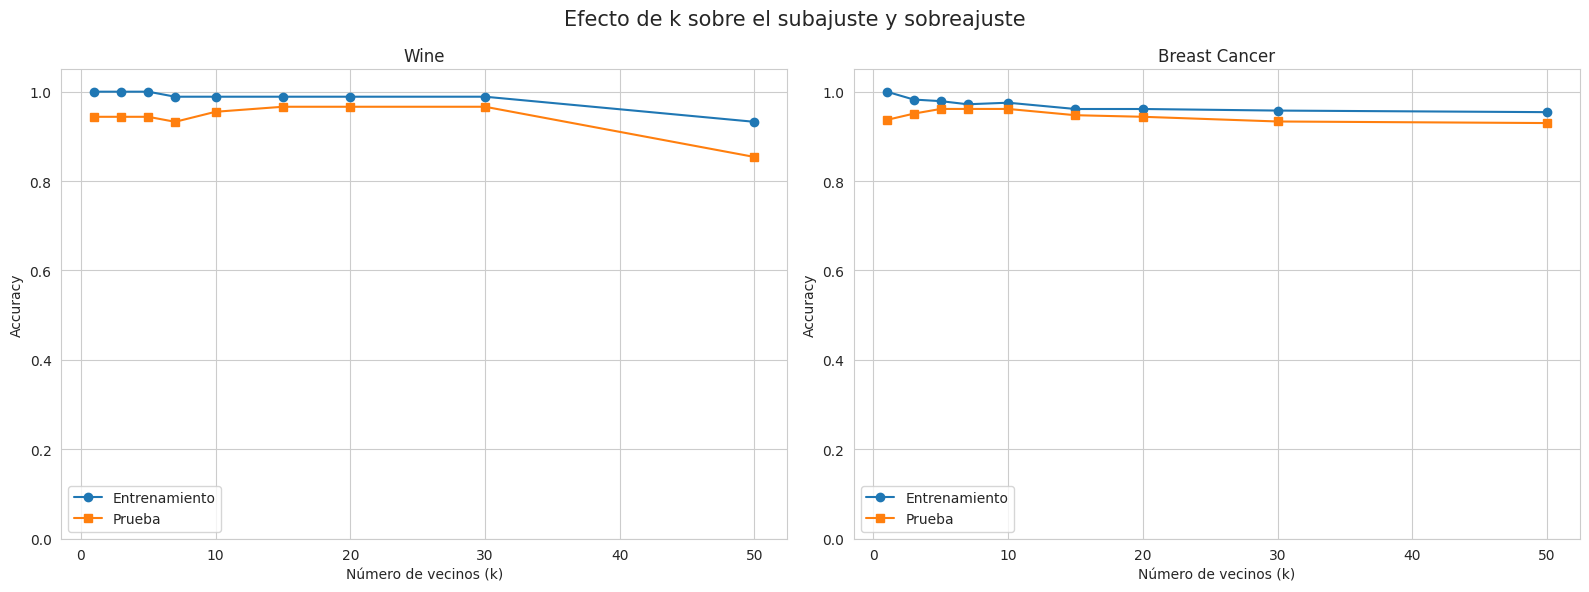

In [ ]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 6)
)

for ax, dataset_nombre in zip(
    axes,
    datasets.keys()
):

    datos = resultados_k_df[
        resultados_k_df["Dataset"] == dataset_nombre
    ]

    ax.plot(
        datos["k"],
        datos["Accuracy train"],
        marker="o",
        label="Entrenamiento"
    )

    ax.plot(
        datos["k"],
        datos["Accuracy test"],
        marker="s",
        label="Prueba"
    )

    ax.set_title(dataset_nombre)
    ax.set_xlabel("Número de vecinos (k)")
    ax.set_ylabel("Accuracy")
    ax.set_ylim(0, 1.05)
    ax.legend()
    ax.grid(True)

plt.suptitle(
    "Efecto de k sobre el subajuste y sobreajuste",
    fontsize=15
)

plt.tight_layout()
plt.show()

IDENTIFICAR SUBAJUSTE Y SOBREAJUSTE

In [ ]:
def diagnosticar_modelo(train_score, test_score):
    diferencia = train_score - test_score

    if train_score < 0.80 and test_score < 0.80:
        return "Posible subajuste"

    elif train_score >= 0.95 and diferencia > 0.08:
        return "Posible sobreajuste"

    else:
        return "Ajuste razonable"


resultados_k_df["Diagnóstico"] = resultados_k_df.apply(
    lambda fila: diagnosticar_modelo(
        fila["Accuracy train"],
        fila["Accuracy test"]
    ),
    axis=1
)

resultados_k_df.round(4)

,Dataset,k,Accuracy train,Accuracy test,Diferencia,Diagnóstico
0,Wine,1,1.0000,0.9438,0.0562,Ajuste razonable
1,Wine,3,1.0000,0.9438,0.0562,Ajuste razonable
2,Wine,5,1.0000,0.9438,0.0562,Ajuste razonable
3,Wine,7,0.9888,0.9326,0.0562,Ajuste razonable
4,Wine,10,0.9888,0.9551,0.0337,Ajuste razonable
5,Wine,15,0.9888,0.9663,0.0225,Ajuste razonable
6,Wine,20,0.9888,0.9663,0.0225,Ajuste razonable
7,Wine,30,0.9888,0.9663,0.0225,Ajuste razonable
8,Wine,50,0.9326,0.8539,0.0787,Ajuste razonable
9,Breast Cancer,1,1.0000,0.9368,0.0632,Ajuste razonable


EVALUACIÓN FINAL CON K = 7


Dataset: Wine
              precision    recall  f1-score   support

           0       0.94      0.97      0.95        30
           1       0.97      0.86      0.91        35
           2       0.89      1.00      0.94        24

    accuracy                           0.93        89
   macro avg       0.93      0.94      0.93        89
weighted avg       0.94      0.93      0.93        89


Dataset: Breast Cancer
              precision    recall  f1-score   support

           0       0.98      0.92      0.95       106
           1       0.95      0.99      0.97       179

    accuracy                           0.96       285
   macro avg       0.97      0.95      0.96       285
weighted avg       0.96      0.96      0.96       285



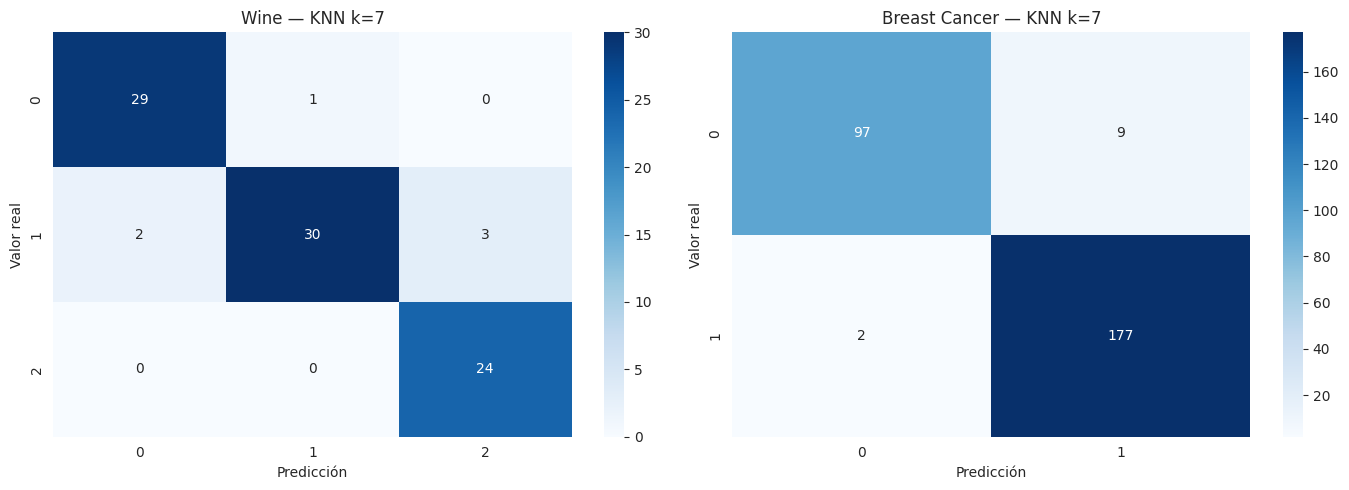

In [ ]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

for ax, (dataset_nombre, (X, y)) in zip(
    axes,
    datasets.items()
):

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.50,
        random_state=42,
        stratify=y
    )

    modelo = Pipeline([
        ("escalador", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=7))
    ])

    modelo.fit(X_train, y_train)

    y_pred = modelo.predict(X_test)

    matriz = confusion_matrix(
        y_test,
        y_pred
    )

    sns.heatmap(
        matriz,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=ax
    )

    ax.set_title(f"{dataset_nombre} — KNN k=7")
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Valor real")

    print(f"\n{'=' * 60}")
    print(f"Dataset: {dataset_nombre}")
    print(f"{'=' * 60}")

    print(
        classification_report(
            y_test,
            y_pred,
            zero_division=0
        )
    )

plt.tight_layout()
plt.show()